# Imports

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonicTesting/')
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonic_ml/src/')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Import Data

AcousticDatabase contains methods to open sqlite file, convert parameters from dict to hdf5 attr friendly format, and setup groups and datasets for raw and preprocessed. Does not contain methods for indexing and retrieving data. These will be specific to the type of experiment we have.

AcousticScanDatabase inhereits from AcousticDatabase. Inherits setup and filing functions for raw and preprocessed. Write your own indexing and filling methods.

In [3]:
# load the database class
import ultrasonic_ml.data.sqlite_acoustic_data as db
import math
from pathlib import Path

filepath = '091626_singleroll_scan_1mm_multiplexer.sqlite3' # for now
p = Path(filepath)

save_folder = '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonic_ml/Notebooks/fft'

database = db.AcousticScanDatabase(save_folder=save_folder, h5_name=p.with_suffix('').name+'.h5', sqlite_path=filepath)

Establishing SQLite connection to database...
Loading h5 parameters...
	Finished.


In [3]:
# # Look at sqlite database structure if you want
# database.print_sqlite_schema()

In [4]:
# # Run ONCE
# # setup and fill the raw data group from sqlite file. 
# #TODO: experimentally check that primary and 2ndary axis steps are correc
# #TODO: sop to always take picture of setup when running UT
# database.sqlite_to_h5()

### Preprocessing

In [5]:
# # Run ONCE
# # setup and fill the preprocessed data group from raw data.
# database.write_preprocessed_data(apply_ungain = False, apply_filter=True, 
#                                  lower_fs_coeff = 1/250, upper_fs_coeff = 1/5, filter_order = 3)

In [6]:
# look at the h5 database structure
database.print_schema()

<HDF5 file "091626_singleroll_scan_1mm_multiplexer.h5" (mode r+)>
|--<HDF5 dataset "config_metadata": shape (), type "|O">
|--<HDF5 group "/preprocessed_data" (2 members)>
|  |--<HDF5 dataset "hilbert": shape (2, 151, 31, 20000), type "<f4">
|  |--<HDF5 dataset "waveforms": shape (2, 151, 31, 20000), type "<f4">
|--<HDF5 group "/raw_data" (2 members)>
|  |--<HDF5 dataset "hilbert": shape (2, 151, 31, 20000), type "<f4">
|  |--<HDF5 dataset "waveforms": shape (2, 151, 31, 20000), type "<f4">


In [7]:
# # look at parameter setup if you want
# database.print_parameters()

In [8]:
# # Look at basic view of mean image and spectrum of raw data
# database.view_mean_img_plot(from_group='preprocessed_data')

### Match first break

In [63]:
# RUN ONCE
# align forward and reverse waveforms to first break and save to h5.
database.write_first_break_aligned_data(from_group='preprocessed_data')

Aligning first break: 9362it [00:17, 530.22it/s]                          

	Finished


/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonic_ml/src/ultrasonic_ml/data/sqlite_acoustic_data.py:995: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


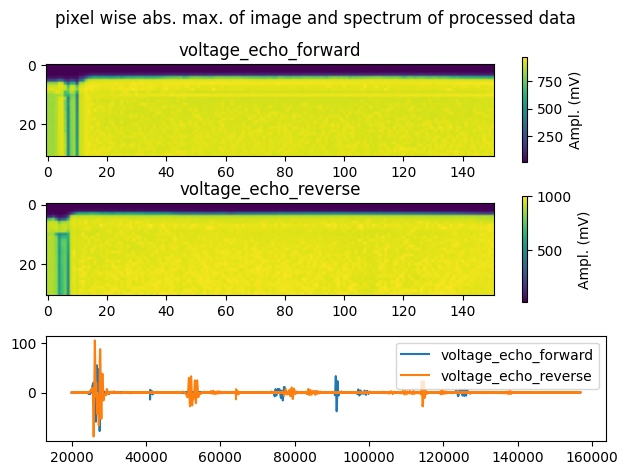

In [64]:
# # Look at basic view of mean image and spectrum of raw data
# database.view_mean_img_plot(from_group='first_break_aligned')

## Interactive visualizer

In [ ]:
import panel as pn
from ultrasonic_ml.viz import sqlite_clickable_viewer as viz

# Run this way to automatically close the class, clear cache, and close affiliated h5 file after use.
with viz.AcousticScanViewer(database, from_group='first_break_aligned') as visualizer:
    app = visualizer.create_dashboard()
    server = pn.serve(app, show=True, threaded=True)
    input("Use the viewer, then press Enter here to close it...")
    server.stop()

Launching server at http://localhost:65397
